In [44]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,  classification_report

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sk.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 2.4.1
Pandas: 3.0.0
Scikit-learn: 1.8.0
Matplotlib: 3.10.8


In [ ]:
Problem 3.2

In [ ]:
a)

In [22]:
X_train = np.array([
 [0.9, 0.8],
 [0.1, 0.2],
 [0.8, 0.6],
 [0.2, 0.3],
 [0.7, 0.9],
 [0.3, 0.1],
 [0.6, 0.7],
 [0.4, 0.4]
])


In [23]:
y_train = np.array([1,0,1,0,1,0,1,0])

In [24]:
model = LogisticRegression(C=1.0, solver='lbfgs')
# Fit the model to training data
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
# Display learned parameters 
print("Learned coefficients:") 
print("  beta_1 (income):", model.coef_[0][0]) 
print("  beta_2 (credit):", model.coef_[0][1]) 
print("  beta_0 (intercept):", model.intercept_[0])

Learned coefficients:
  beta_1 (income): 0.7844652812344056
  beta_2 (credit): 0.7844188205832026
  beta_0 (intercept): -0.784597347924263


In [29]:
# Compute odds ratios
odds_ratios = np.exp(model.coef_[0])
print("Odds Ratios:")
print("Recency:", odds_ratios[0])
print("Frequency:", odds_ratios[1])

Odds Ratios:
Recency: 2.1912349329753824
Frequency: 2.191133129138412


In [ ]:
b)

In [31]:
 # Get predicted probabilities
probs = model.predict_proba(X_train)

for i in range(len(probs)):
    print("Customer", i + 1,
          ": P(No) =", round(probs[i][0], 3),
          ", P(Yes) =", round(probs[i][1], 3))


Customer 1 : P(No) = 0.366 , P(Yes) = 0.634
Customer 2 : P(No) = 0.634 , P(Yes) = 0.366
Customer 3 : P(No) = 0.422 , P(Yes) = 0.578
Customer 4 : P(No) = 0.597 , P(Yes) = 0.403
Customer 5 : P(No) = 0.384 , P(Yes) = 0.616
Customer 6 : P(No) = 0.616 , P(Yes) = 0.384
Customer 7 : P(No) = 0.441 , P(Yes) = 0.559
Customer 8 : P(No) = 0.539 , P(Yes) = 0.461


In [35]:
 # Generate class predictions
y_pred = model.predict(X_train)
 # Calculate accuracy 
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_train, y_pred) 
print("Training accuracy:", accuracy * 100, "%") 
# Compute confusion matrix
print(confusion_matrix(y_train, y_pred))
# Display classification report
print(classification_report(y_train, y_pred))

Training accuracy: 100.0 %
[[4 0]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



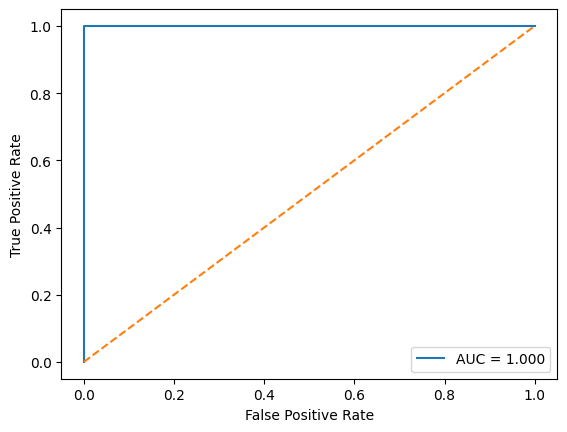

In [38]:
# Compute ROC-AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X)[:, 1]
auc = roc_auc_score(y, y_prob)

fpr, tpr, _ = roc_curve(y, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
c)

In [43]:
# New customer from part (c)
new_customer = np.array([[0.55, 0.65]])

# Predicted probability
probability = model.predict_proba(new_customer)[0, 1]

# Classification using optimal threshold
optimal_threshold = 0.3
prediction = "Respond" if probability >= optimal_threshold else "No Response"

print("Predicted probability:", round(probability, 4))
print("Prediction:", prediction)


Predicted probability: 0.5391
Prediction: Respond


In [ ]:
b)

In [ ]:
email_cost = 0.5
revenue_per_response = 25

break_even = email_cost / revenue_per_response

print(f"Break-even probability: {break_even:.3f}")

In [ ]:
predicted_probabilities = y_prob 

target_customers = predicted_probabilities[predicted_probabilities > break_even]

print(f"Customers selected for campaign: {len(target_customers)}")
print(f"Minimum selected probability: {target_customers.min():.3f}")
